# Graded Response Model — WPI (Single Scale)

Fits a single-dimensional GRM to all 116 WPI items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.wpi import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary 0-1)")
df.head()

Dataset shape: (6019, 117)
Number of people: 6019
Number of items: 116
Response cardinality: 2 (binary 0-1)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,…,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,Q97,Q98,Q99,Q100,Q101,Q102,Q103,Q104,Q105,Q106,Q107,Q108,Q109,Q110,Q111,Q112,Q113,Q114,Q115,Q116
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,0,0,0,1,1,0,1,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0,0,…,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,1,1,0
1,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,-1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,0,1,1,0,1,0,0,1,1,1,1,0,1,1,-1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,0,0,0
2,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,0,0,1,0,0,0,1,…,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,-1,0,1,0,1,1,0,0,0,0,0,1
3,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0,…,1,1,1,1,1,0,1,1,1,1,0,1,0,0,0,0,0,1,1,1,0,1,1,1,1,1,1,1,1,0,1,0,1,0,0,0,0
4,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 6019


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 6334
N: 6019, Batch size: 256, Steps per epoch: 24


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200

losses_baseline, params_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Final loss: {losses_baseline[-1]:.2f}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:03<?, ?batch/s, best_loss=inf, loss=21740.4098]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:03<01:20,  3.51s/batch, best_loss=inf, loss=21740.4098]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:03<01:20,  3.51s/batch, best_loss=inf, loss=21732.6865]

...

Epoch 200/200 (LR: 0.000200):  75%|███████▌  | 18/24 [00:00<00:00, 58.07batch/s, best_loss=16884.0792, loss=17210.3333]

Epoch 200/200 (LR: 0.000200):  75%|███████▌  | 18/24 [00:00<00:00, 58.07batch/s, best_loss=16884.0792, loss=17370.9828]

Epoch 200/200 (LR: 0.000200):  75%|███████▌  | 18/24 [00:00<00:00, 58.07batch/s, best_loss=16884.0792, loss=17236.3681]

Epoch 200/200 (LR: 0.000200):  75%|███████▌  | 18/24 [00:00<00:00, 58.07batch/s, best_loss=16884.0792, loss=9008.5926] 

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Final loss: 16874.28


In [6]:
model_baseline.save_to_disk('grm_baseline')

## 4. Fit MICEBayesianLOO Imputation Model

In [7]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas with NaN for missing (MICEBayesianLOO expects pandas)
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, np.nan)
print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"NaN count: {imputation_df.isna().sum().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    X_df=imputation_df,
    n_top_features=30,
    n_jobs=-1,
    fit_zero_predictors=True,
    seed=42,
)

print(f"\nFitted variable names: {mice_loo.variable_names[:5]}...")
print(f"Zero-predictor models: {len(mice_loo.zero_predictor_results)}")
print(f"Univariate models: {len(mice_loo.univariate_results)}")

Imputation DataFrame shape: (6019, 116)
NaN count: 6334
Computing feature correlations...


Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 116
  Observations: 6019
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 30

Fitting zero-predictor models...
  Scheduling 116 zero-predictor jobs...


  Var 0 (Q1): n_obs=6005, elpd/n=-0.0569
  Var 1 (Q2): n_obs=5996, elpd/n=-0.0589
  Var 2 (Q3): n_obs=5988, elpd/n=-0.0432
  Var 3 (Q4): n_obs=5995, elpd/n=-0.0455
  Var 4 (Q5): n_obs=5992, elpd/n=-0.0588
  Var 5 (Q6): n_obs=6004, elpd/n=-0.0361
  Var 6 (Q7): n_obs=5985, elpd/n=-0.0239
  Var 7 (Q8): n_obs=5990, elpd/n=-0.0592
  Var 8 (Q9): n_obs=5979, elpd/n=-0.0540


  Var 9 (Q10): n_obs=5988, elpd/n=-0.0477
  Var 10 (Q11): n_obs=5987, elpd/n=-0.0561
  Var 11 (Q12): n_obs=5979, elpd/n=-0.0541
  Var 12 (Q13): n_obs=5986, elpd/n=-0.0566


  Var 13 (Q14): n_obs=5955, elpd/n=-0.0361
  Var 14 (Q15): n_obs=5975, elpd/n=-0.0406
  Var 15 (Q16): n_obs=5956, elpd/n=-0.0499
  Var 16 (Q17): n_obs=5966, elpd/n=-0.0492
  Var 17 (Q18): n_obs=5964, elpd/n=-0.0585
  Var 18 (Q19): n_obs=5977, elpd/n=-0.0594
  Var 19 (Q20): n_obs=5956, elpd/n=-0.0574
  Var 20 (Q21): n_obs=5965, elpd/n=-0.0581
  Var 21 (Q22): n_obs=5961, elpd/n=-0.0568
  Var 22 (Q23): n_obs=5956, elpd/n=-0.0464
  Var 23 (Q24): n_obs=5962, elpd/n=-0.0534
  Var 24 (Q25): n_obs=5945, elpd/n=-0.0492
  Var 25 (Q26): n_obs=5959, elpd/n=-0.0152


...

  Processing Q113 (30 valid predictors)


  Processing Q114 (30 valid predictors)


  Processing Q115 (30 valid predictors)


  Processing Q116 (30 valid predictors)



Fitted variable names: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']...
Zero-predictor models: 116
Univariate models: 3480


In [8]:
mice_loo.save('mice_loo_model.yaml')

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [9]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
    imputation_model=mice_loo,
)

# Validate the imputation model
model_imputed.validate_imputation_model()
print("Imputation model validation passed.")

losses_imputed, params_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Final loss: {losses_imputed[-1]:.2f}")

/home/josh/workspace/bayesianquilts/python/bayesianquilts/irt/irt.py:220: UserWarning: Items with high PSIS khat (>= 0.7), imputation may be unreliable: ['Q48']
  warnings.warn(


Imputation model validation passed.
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:03<?, ?batch/s, best_loss=inf, loss=21732.9749]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:03<01:09,  3.02s/batch, best_loss=inf, loss=21732.9749]

...

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:01<00:00, 10.89batch/s, best_loss=16876.3176, loss=17071.4688]

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:02<00:00, 10.89batch/s, best_loss=16876.3176, loss=17068.2164]

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:02<00:00, 10.89batch/s, best_loss=16876.3176, loss=9279.0624] 

Epoch 200/200 (LR: 0.000200): 100%|██████████| 24/24 [00:02<00:00, 11.47batch/s, best_loss=16876.3176, loss=9279.0624]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Final loss: 16866.96


In [10]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

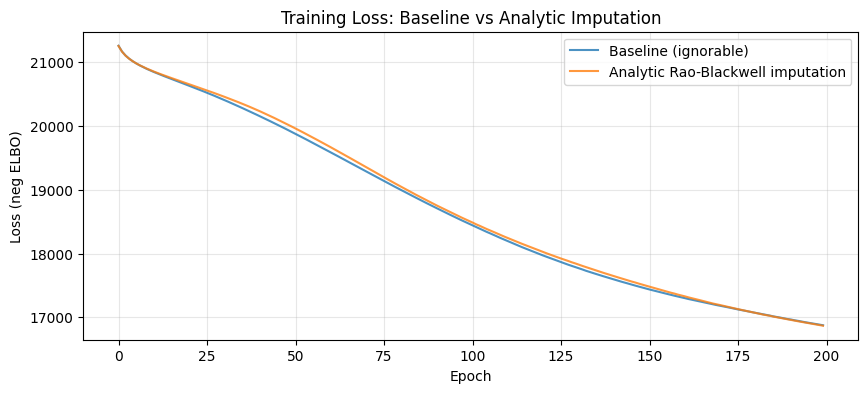

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(losses_baseline, label='Baseline (ignorable)', alpha=0.8)
plt.plot(losses_imputed, label='Analytic Rao-Blackwell imputation', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (neg ELBO)')
plt.title('Training Loss: Baseline vs Analytic Imputation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def calibrate_manually(model, n_samples=32, seed=42):
    surrogate = model.surrogate_distribution_generator(model.params)
    key = jax.random.PRNGKey(seed)
    samples = surrogate.sample(n_samples, seed=key)
    expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
    model.calibrated_expectations = expectations
    model.surrogate_sample = samples

calibrate_manually(model_baseline, n_samples=32, seed=101)
calibrate_manually(model_imputed, n_samples=32, seed=102)

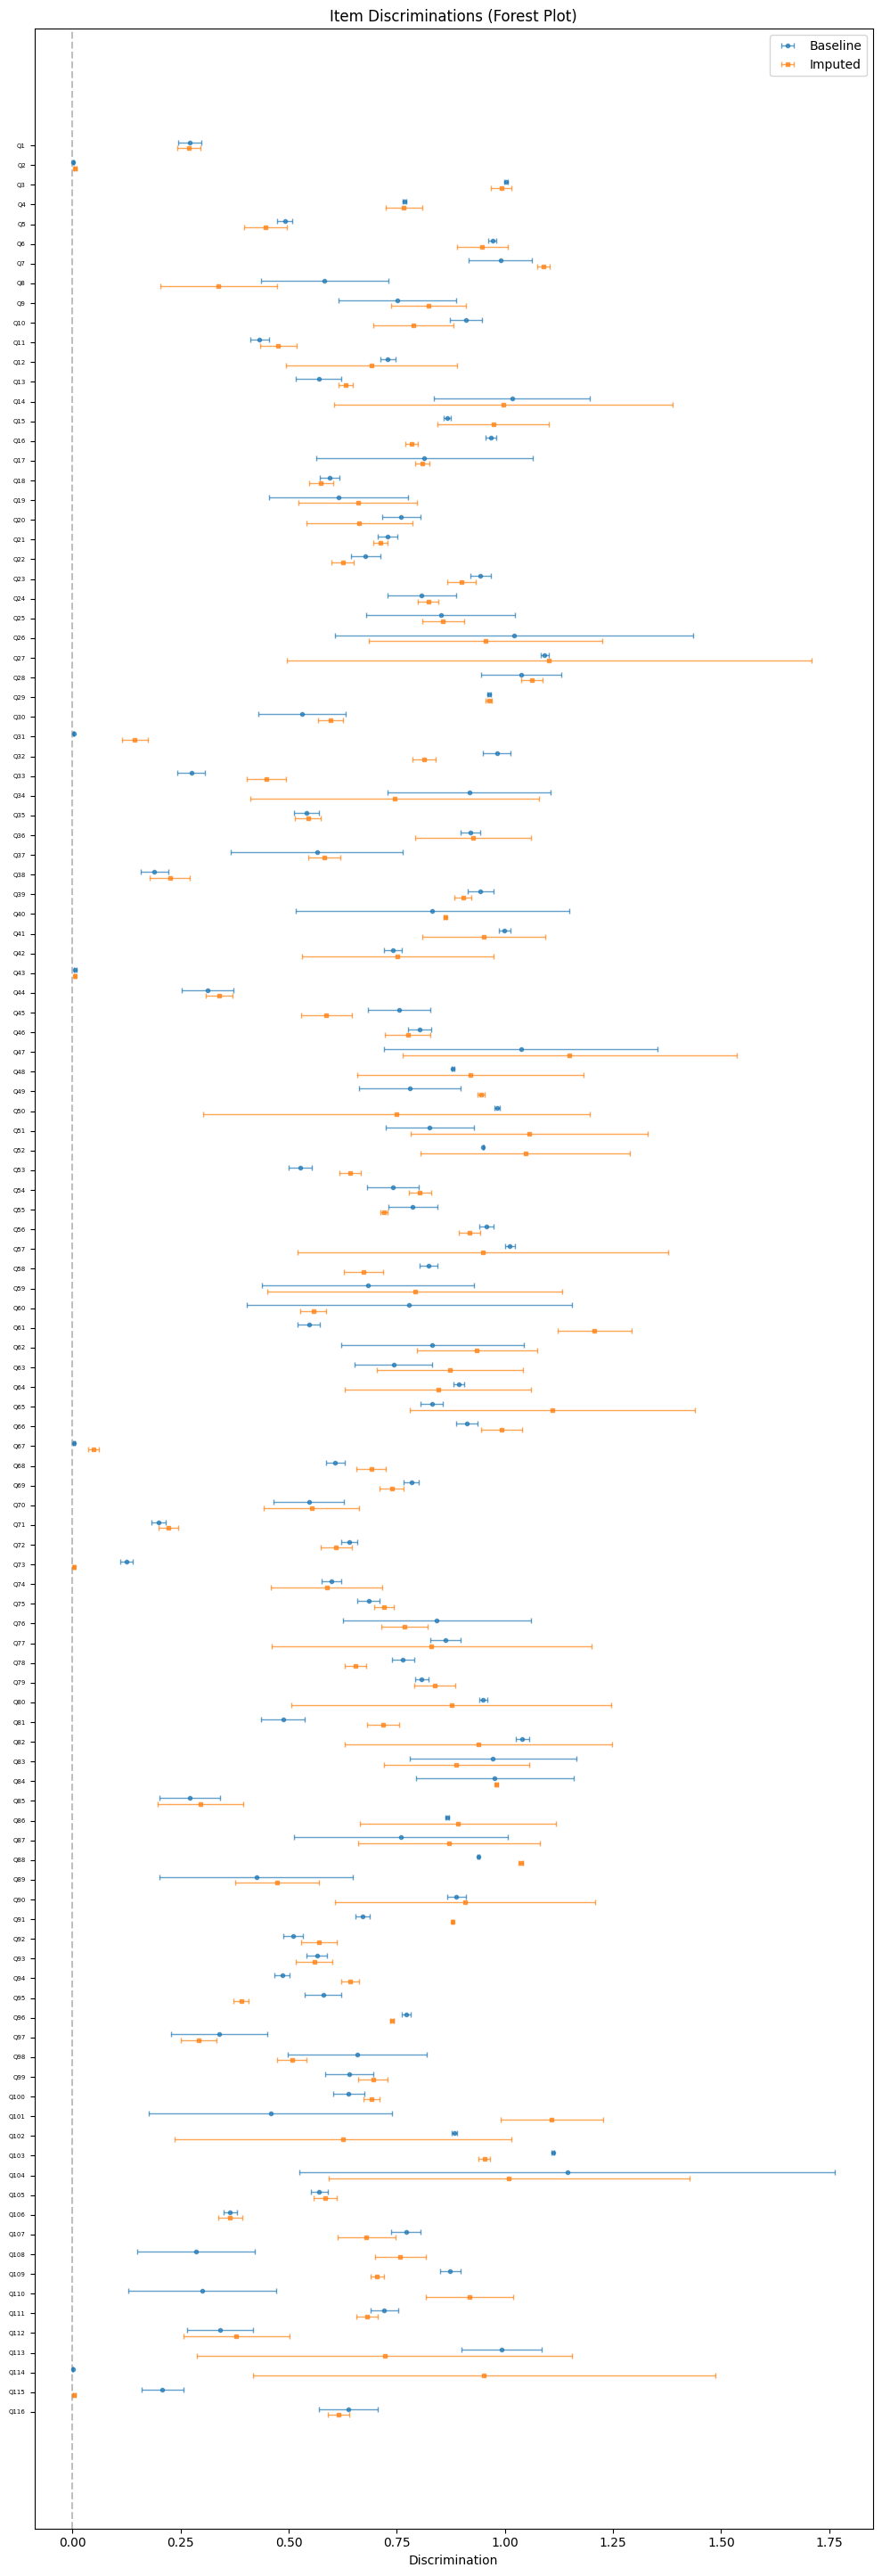

In [13]:
# Forest plot of discriminations with uncertainty
disc_samples_base = np.array(model_baseline.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))
disc_samples_imp = np.array(model_imputed.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))

disc_mean_base = disc_samples_base.mean(axis=0)
disc_std_base = disc_samples_base.std(axis=0)
disc_mean_imp = disc_samples_imp.mean(axis=0)
disc_std_imp = disc_samples_imp.std(axis=0)

fig, ax = plt.subplots(figsize=(10, max(7, len(item_keys) * 0.25)))
y_pos = np.arange(len(item_keys))
offset = 0.15

ax.errorbar(disc_mean_base, y_pos - offset, xerr=disc_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            ecolor='tab:blue', alpha=0.7, label='Baseline')
ax.errorbar(disc_mean_imp, y_pos + offset, xerr=disc_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            ecolor='tab:orange', alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels(item_keys, fontsize=5)
ax.set_xlabel('Discrimination')
ax.set_title('Item Discriminations (Forest Plot)')
ax.legend()
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(ab_base, ab_imp, alpha=0.3, s=10, edgecolors='none')
lims = [min(ab_base.min(), ab_imp.min()), max(ab_base.max(), ab_imp.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Baseline Ability')
ax.set_ylabel('Imputed Ability')
ax.set_title('Ability Estimates: Baseline vs Imputed')
ax.legend()
ax.set_aspect('equal')

ax = axes[1]
ax.hist(ab_base, bins=30, histtype='step', linewidth=2, label='Baseline', color='tab:blue')
ax.hist(ab_imp, bins=30, histtype='step', linewidth=2, label='Imputed', color='tab:orange')
ax.set_xlabel('Ability (latent trait)')
ax.set_ylabel('Count')
ax.set_title('Ability Distribution')
ax.legend()

plt.tight_layout()
plt.show()

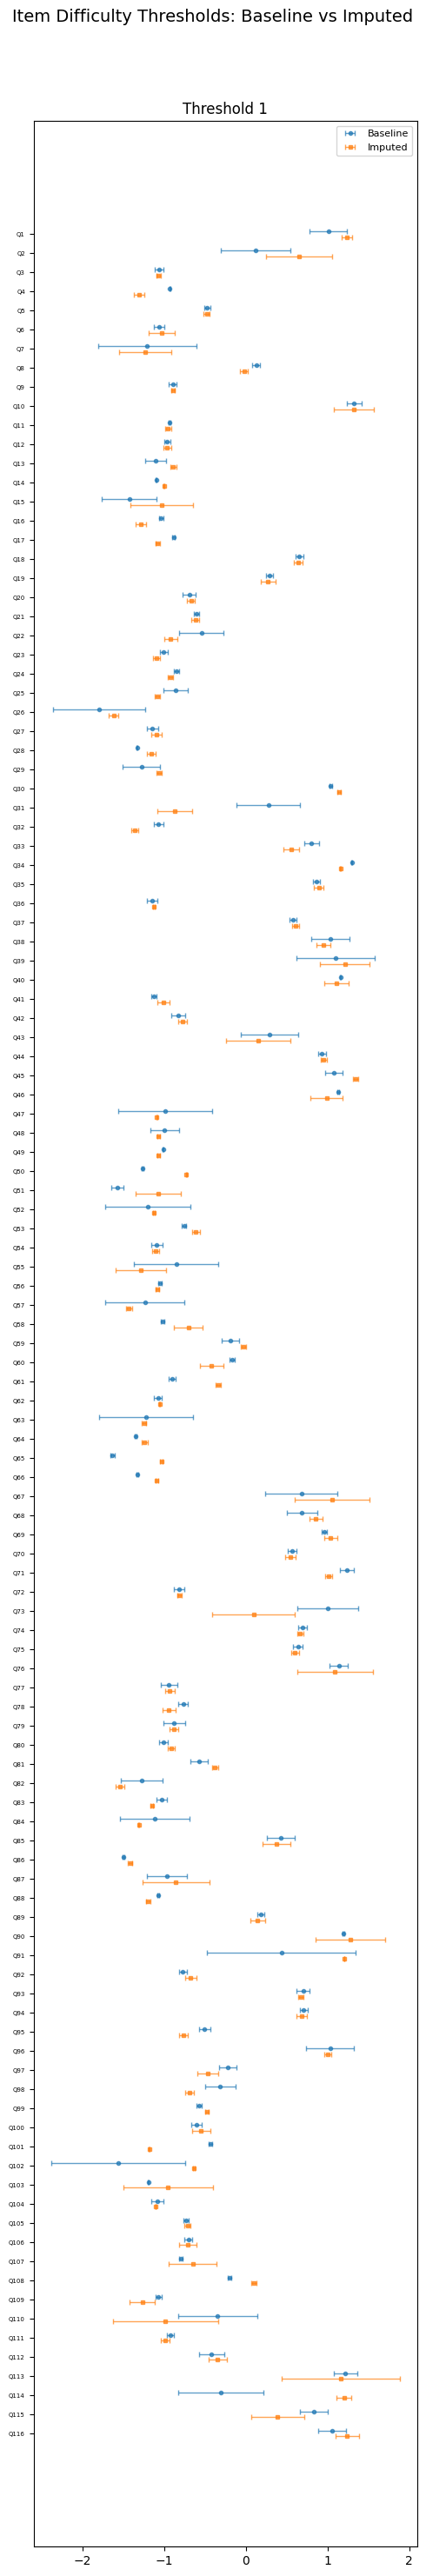

In [15]:
# Difficulty threshold comparison
def compute_thresholds(model):
    diff0 = np.array(model.surrogate_sample['difficulties0'])
    ddiff = np.array(model.surrogate_sample['ddifficulties'])
    d0 = np.concatenate([diff0, ddiff], axis=-1)
    thresholds = np.cumsum(d0, axis=-1)
    n_samples = thresholds.shape[0]
    n_thresholds = thresholds.size // (n_samples * len(item_keys))
    return thresholds.reshape(n_samples, len(item_keys), n_thresholds)

thresh_base = compute_thresholds(model_baseline)
thresh_imp = compute_thresholds(model_imputed)

K_minus_1 = thresh_base.shape[-1]
n_cols = min(4, K_minus_1)
n_rows = int(np.ceil(K_minus_1 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(5 * n_cols, max(7, len(item_keys) * 0.25) * n_rows),
    squeeze=False)

for level in range(K_minus_1):
    ax = axes[level // n_cols, level % n_cols]
    y_pos = np.arange(len(item_keys))

    mean_base = thresh_base[:, :, level].mean(axis=0)
    std_base = thresh_base[:, :, level].std(axis=0)
    mean_imp = thresh_imp[:, :, level].mean(axis=0)
    std_imp = thresh_imp[:, :, level].std(axis=0)

    offset = 0.15
    ax.errorbar(mean_base, y_pos - offset, xerr=std_base, fmt='o',
                capsize=2, markersize=3, elinewidth=1, color='tab:blue',
                alpha=0.7, label='Baseline')
    ax.errorbar(mean_imp, y_pos + offset, xerr=std_imp, fmt='s',
                capsize=2, markersize=3, elinewidth=1, color='tab:orange',
                alpha=0.7, label='Imputed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(item_keys, fontsize=5)
    ax.set_title(f'Threshold {level + 1}')
    ax.invert_yaxis()
    if level == 0:
        ax.legend(fontsize=8)

for idx in range(K_minus_1, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Item Difficulty Thresholds: Baseline vs Imputed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

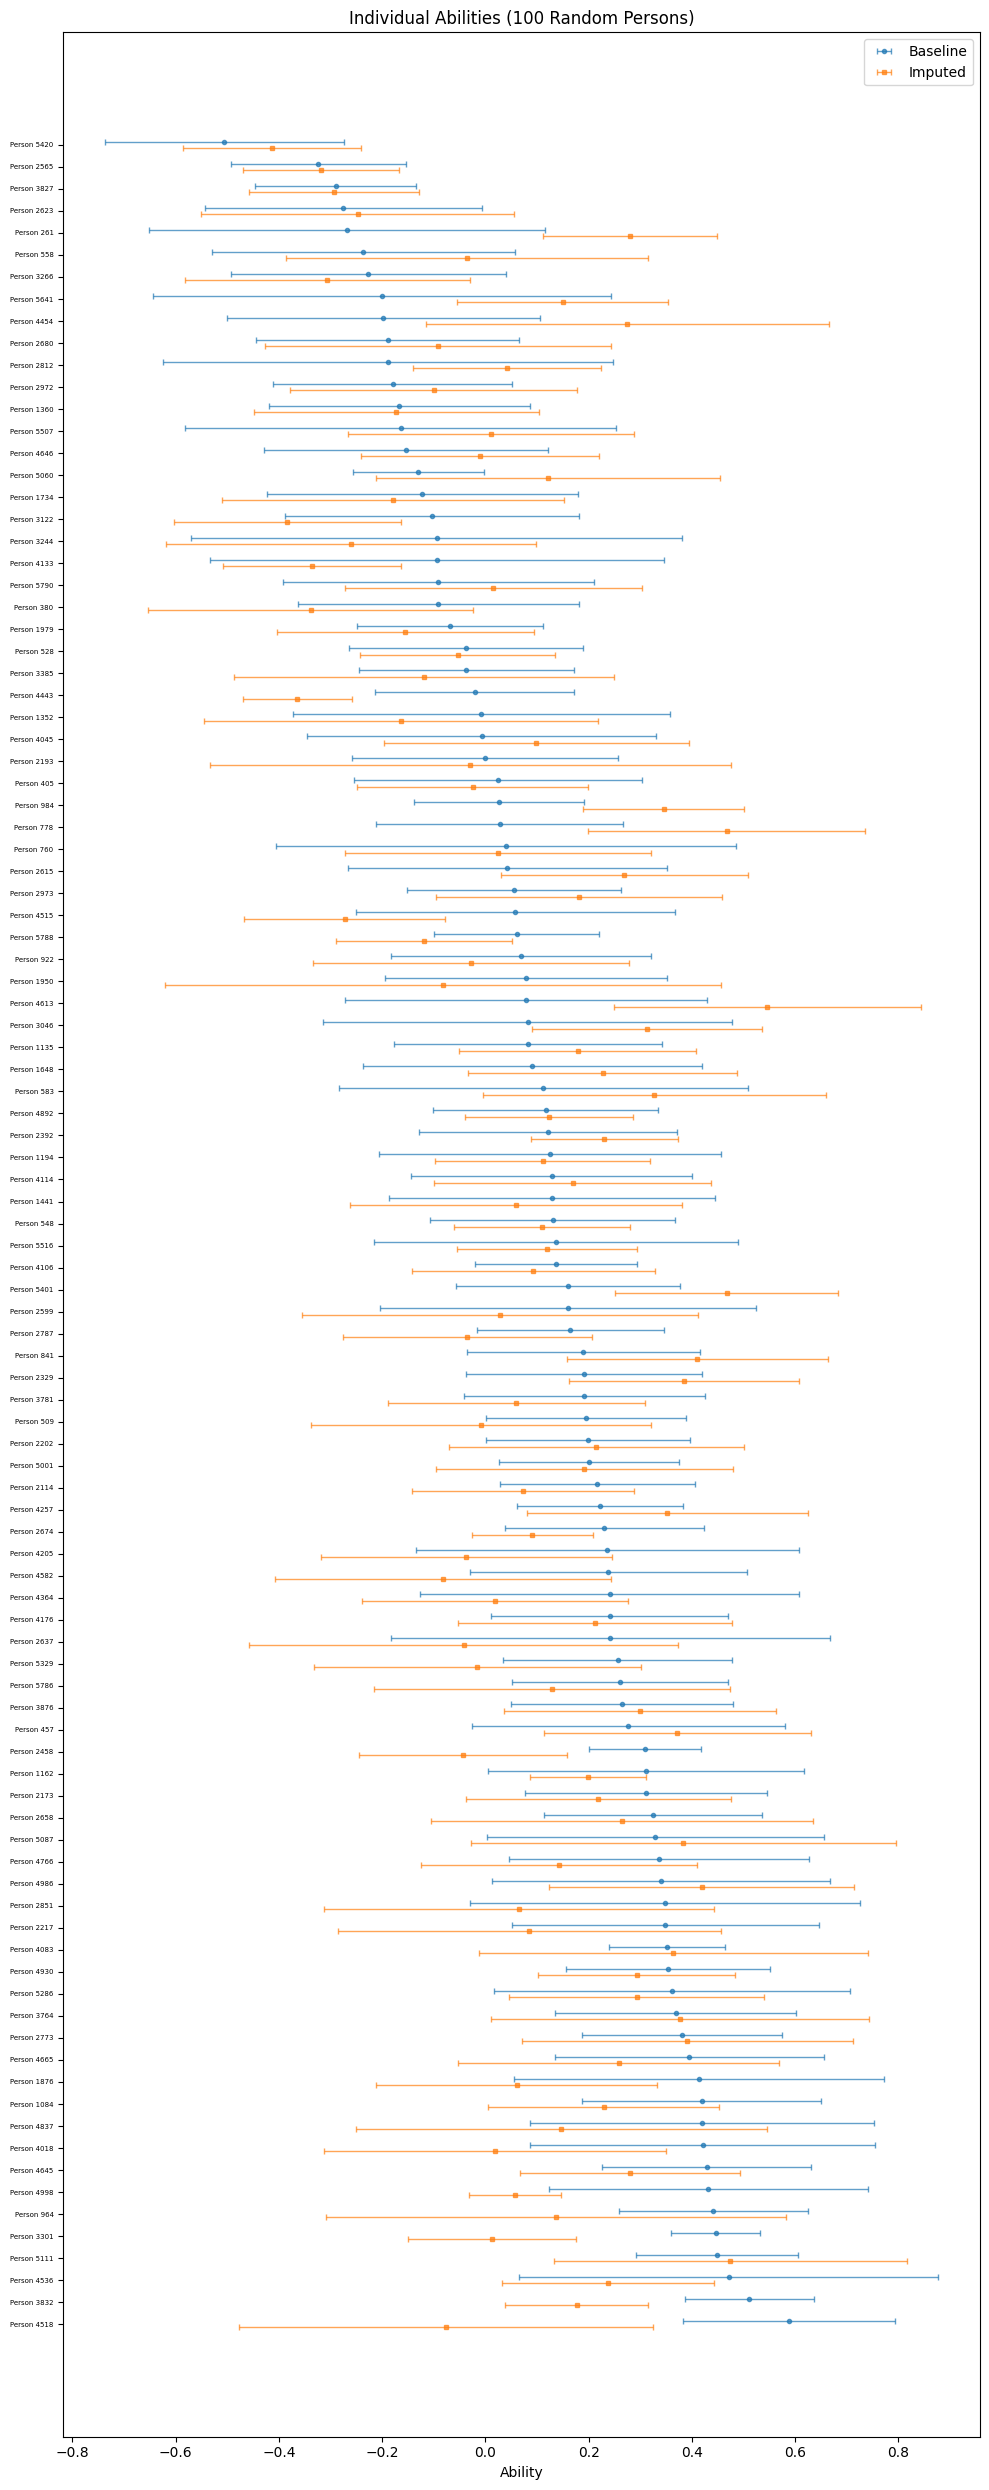

In [16]:
# Forest plot comparing abilities for 100 random individuals
ab_samples_base = np.array(model_baseline.surrogate_sample['abilities'])
ab_samples_imp = np.array(model_imputed.surrogate_sample['abilities'])

ab_samples_base = ab_samples_base.reshape(ab_samples_base.shape[0], -1)
ab_samples_imp = ab_samples_imp.reshape(ab_samples_imp.shape[0], -1)

N = ab_samples_base.shape[1]
rng = np.random.default_rng(42)
idx = rng.choice(N, size=min(100, N), replace=False)
idx = np.sort(idx)

ab_mean_base = ab_samples_base[:, idx].mean(axis=0)
ab_std_base = ab_samples_base[:, idx].std(axis=0)
ab_mean_imp = ab_samples_imp[:, idx].mean(axis=0)
ab_std_imp = ab_samples_imp[:, idx].std(axis=0)

order = np.argsort(ab_mean_base)
ab_mean_base = ab_mean_base[order]
ab_std_base = ab_std_base[order]
ab_mean_imp = ab_mean_imp[order]
ab_std_imp = ab_std_imp[order]

fig, ax = plt.subplots(figsize=(10, 25))
y_pos = np.arange(len(idx))
offset = 0.15

ax.errorbar(ab_mean_base, y_pos - offset, xerr=ab_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            alpha=0.7, label='Baseline')
ax.errorbar(ab_mean_imp, y_pos + offset, xerr=ab_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Person {i}' for i in idx[order]], fontsize=5)
ax.set_xlabel('Ability')
ax.set_title('Individual Abilities (100 Random Persons)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated fitting a single-scale GRM (equivalent to a 2PL model
for binary items) to the 116-item Woodworth Psychoneurotic Inventory:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   zeroed out.
2. **MICEBayesianLOO imputation**: A Bayesian LOO-CV stacking model predicts missing
   items from observed ones.
3. **Analytic Rao-Blackwellized imputation**: The GRM analytically marginalizes over
   the imputation PMFs for missing cells, yielding zero-variance imputation
   contributions.

Discrimination and ability estimates from both approaches can be compared to assess
the impact of the missingness-handling strategy.